# 🟢 Colab E-iii — TensorFlow Functional API
**Input → Dense chain → tf.keras.Model → compile + fit**

In [1]:
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt
tf.random.set_seed(42); np.random.seed(42)
print('TF:', tf.__version__)

TF: 2.19.0


## 📊 Section 1 — Data

In [2]:
N=1000
x1=np.random.uniform(-2,2,(N,1)); x2=np.random.uniform(-2,2,(N,1)); x3=np.random.uniform(-2,2,(N,1))
y=2*x1**2+3*x2*x3+np.sin(x1*x2)+0.5*x3**2+np.random.normal(0,0.1,(N,1))
X=np.hstack([x1,x2,x3])
X_n=(X-X.mean(0))/X.std(0); y_mean,y_std=float(y.mean()),float(y.std()); y_n=(y-y_mean)/y_std
sp=int(0.8*N)
Xtr,Xte=X_n[:sp].astype('float32'),X_n[sp:].astype('float32')
Ytr,Yte=y_n[:sp].astype('float32'),y_n[sp:].astype('float32')

## 🏗️ Section 2 — Functional API Model

In [3]:
# Build model as computation graph: Input → layers → Model
inputs = tf.keras.Input(shape=(3,), name='input')
x = tf.keras.layers.Dense(64, activation='relu',  kernel_initializer='he_normal', name='hidden1')(inputs)
x = tf.keras.layers.Dense(32, activation='relu',  kernel_initializer='he_normal', name='hidden2')(x)
x = tf.keras.layers.Dense(16, activation='tanh',  name='hidden3')(x)
outputs = tf.keras.layers.Dense(1, name='output')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs, name='regression_net')
model.summary()

Model: "regression_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden1 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

## 🏋️ Section 3 — compile + fit with Callbacks

In [4]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse',
    metrics=['mae']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=60,
                                      restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=30, verbose=1)
]

history = model.fit(
    Xtr, Ytr,
    epochs=1000, batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.9293 - mae: 0.7738 - val_loss: 0.5004 - val_mae: 0.5928 - learning_rate: 0.0010
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3580 - mae: 0.4860 - val_loss: 0.2820 - val_mae: 0.4342 - learning_rate: 0.0010
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2391 - mae: 0.3920 - val_loss: 0.2204 - val_mae: 0.3766 - learning_rate: 0.0010
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1984 - mae: 0.3537 - val_loss: 0.1894 - val_mae: 0.3421 - learning_rate: 0.0010
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1713 - mae: 0.3276 - val_loss: 0.1675 - val_mae: 0.3149 - learning_rate: 0.0010
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1512 - mae: 0.3059 - val_loss: 0.1495 - val_mae: 0.2891 - learning_rate: 0.0010
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1350 - mae: 0.2885 - val_loss: 0.1325 - val_mae: 0.2667 - learning_rate: 0.0010
Epoch

## 📈 Section 4 — Results

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


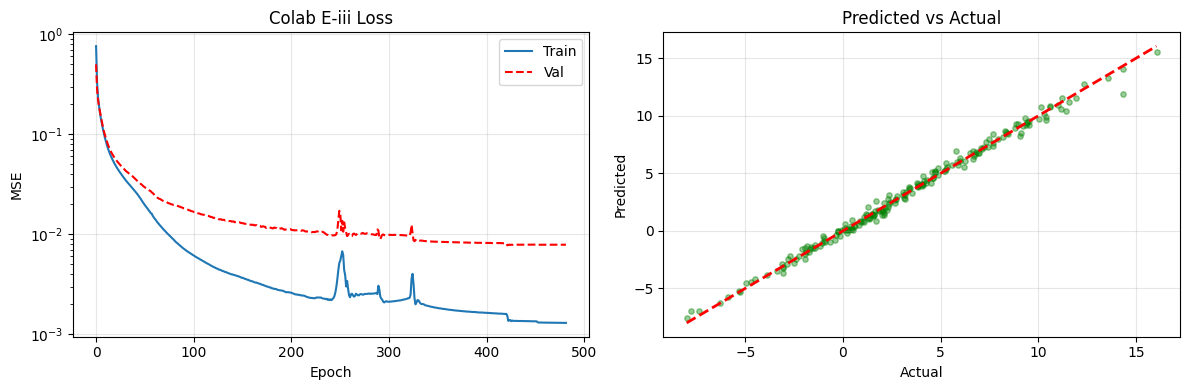

Test MSE: 0.1489


In [5]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].semilogy(history.history['loss'],label='Train')
axes[0].semilogy(history.history['val_loss'],'r--',label='Val')
axes[0].set(title='Colab E-iii Loss',xlabel='Epoch',ylabel='MSE')
axes[0].legend(); axes[0].grid(alpha=0.3)

yp=model.predict(Xte)*y_std+y_mean; yt=Yte*y_std+y_mean
axes[1].scatter(yt,yp,alpha=0.4,s=15,color='green')
mn,mx=yt.min(),yt.max(); axes[1].plot([mn,mx],[mn,mx],'r--',lw=2)
axes[1].set(title='Predicted vs Actual',xlabel='Actual',ylabel='Predicted')
axes[1].grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'Test MSE: {((yp-yt)**2).mean():.4f}')